## 0.&nbsp;Gathering Data and Exploration

### 0.1&nbsp;Loading libraries and Data

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path


output_dir = Path(r"../data/processed/plots")
output_dir.mkdir(parents=True, exist_ok=True)

BATCH = "batch_dist_binary_ethanol+propan-2-ol"            
# BATCH = "batch_dist_ternary_acetone+butan-1-ol+methanol"
# BATCH = "batch_dist_ternary_butan-1-ol+propan-2-ol+water"

OPERATING_POINT = "operating_point_001"
TEST = "test_anormal_experiment_001"    
# TEST = "train_normal_experiment_001"

MAPPING = "plant_description_bd+v1_mapping"

PATH = f"{BATCH}/{OPERATING_POINT}/{TEST}"

ANOMALY_META_YAML = f"../data/raw//00_Timeseries_Label_Anomaly_Metadata/Operation/{PATH}.yaml"
OPERATION_ANOMALY = f"../data/raw//00_Timeseries_Label_Anomaly_Metadata/Operation/{PATH}.csv"
OPERATION_SENSORS = f"../data/raw/01_Timeseries_Sensors/Operation/{PATH}.csv"
STARTUP_SENSORS = f"../data/raw/01_Timeseries_Sensors/Startup/{PATH}.csv"
SHUTDOWN_SENSOR = f"../data/raw/01_Timeseries_Sensors/Shutdown/{PATH}.csv"
OPERATION_ACTUATORS = f"../data/raw/02_Timeseries_Actuators/Operation/{PATH}.csv"
STARTUP_ACTUATORS = f"../data/raw/02_Timeseries_Actuators/Startup/{PATH}.csv"
SHUTDOWN_ACTUATORS = f"../data/raw/02_Timeseries_Actuators/Shutdown/{PATH}.csv"


# Single time use
PLANT_DESCRIPTION_YAML = f"../data/raw/06_Tabular_Plant_Information/{BATCH}/{OPERATING_POINT}/{TEST}/{MAPPING}.yaml"
PLANT_SETTINGS = f"../data/raw/06_Tabular_Plant_Information/{BATCH}/{OPERATING_POINT}/{TEST}/settings.csv"
MODALITY_AVAILABILITY_MATRIX = f"../data/raw/Batch_Distillation_Plant_M-202210_Modality_Availability_Matrix.csv"

In [30]:
with open(ANOMALY_META_YAML, "r", encoding="utf-8") as file:
    anomaly_meta = yaml.safe_load(file)

operation_anomaly = pd.read_csv(OPERATION_ANOMALY)
operation_sensors = pd.read_csv(OPERATION_SENSORS)
startup_sensors = pd.read_csv(STARTUP_SENSORS)
shutdown_sensors = pd.read_csv(SHUTDOWN_SENSOR)
operation_actuators = pd.read_csv(OPERATION_ACTUATORS)
startup_actuators = pd.read_csv(STARTUP_ACTUATORS)
shutdown_actuators = pd.read_csv(SHUTDOWN_ACTUATORS)

with open(PLANT_DESCRIPTION_YAML, "r", encoding="utf-8") as file:
    plant_description = yaml.safe_load(file)

plant_settings = pd.read_csv(PLANT_SETTINGS)


modality_availability_matrix = pd.read_csv(MODALITY_AVAILABILITY_MATRIX)

## 1.&nbsp;Data Inspection

### 1.1&nbsp;Modality Availability Matrix

In [31]:
# overview over all experiments: 
modality_availability_matrix;

### 1.1&nbsp;Anomaly Meta Data

In [32]:
rows = []

for anomaly in anomaly_meta["anomalies"]:

    observation = anomaly["wasOriginatedBy"]["Observation"]

    rows.append({
        "anomaly_id": anomaly["id"],
        "beginning": anomaly["hasBeginning"],
        "end": anomaly["hasEnd"],
        "sensor": observation["madeBySensor"]["Sensor"]["id"],
        "observation": observation["label"],
        "property": observation["observedProperty"]["ObservableProperty"],
        "feature_of_interest": observation["hasFeatureOfInterest"]["FeatureOfInterest"]
    })

anomaly_events = pd.DataFrame(rows)

### 1.2&nbsp;Anomaly Time Series Data

In [33]:
operation_anomaly.loc[
    operation_anomaly["Time"].between("12:13:15", "12:15:26")
];

### 1.3&nbsp;Sensors (Startup - Operation - Shutdown)

In [34]:
startup_sensors.shape,startup_sensors.head();

In [35]:
operation_sensors.shape,operation_sensors.head();

In [36]:
shutdown_sensors.shape, shutdown_sensors.head();

### 1.4&nbsp;Actuators (Startup - Operation - Shutdown)

In [37]:
startup_actuators.shape,startup_actuators.head();

In [38]:
operation_actuators.shape,operation_actuators.head();

In [39]:
shutdown_actuators.shape,shutdown_actuators.head();

### 1.5&nbsp;Plant Description and Settings

In [41]:
plant_description['plant']['name']

'Batch Distillation Plant V1'

In [42]:
plant_description.keys()

dict_keys(['plant', 'actuator', 'equipment', 'sensor'])

Check for plant description keys: actuator, equipment, sensor

In [43]:
pd.DataFrame(plant_description['actuator']);

In [44]:
plant_settings

,Index,Property,Value,Unit
0,0,operated_plant,Batch Distillation Plant V1,-
1,1,operator,2,-
2,2,operating_point_pressure,300,mbar
3,3,operating_point_reflux_ratio_set,0.2,-
4,4,operating_point_heating_power_H701,175,W
5,5,operating_point_heating_power_H002,0,W
6,6,operating_point_cooling_temperature,10,°C
7,7,setpoint_controller_H702,70.0,°C constant
8,8,setpoint_controller_H704,70.0,°C constant
9,9,setpoint_controller_H706,70.0,°C constant


## 2. Data Preparation

### 2.1&nbsp;Merge sensors and actuators time series (startup - operation - shutdown) including 'phase'

In [45]:
exp_startup = pd.merge(
    startup_sensors,
    startup_actuators, 
    on='Time', 
    how='inner'
)
exp_startup['phase']="startup"

In [46]:
exp_operation = pd.merge(
    operation_sensors,
    operation_actuators, 
    on='Time', 
    how='inner'
)

exp_operation['phase']="operation"

In [47]:
exp_shutdown = pd.merge(
    shutdown_sensors,
    shutdown_actuators, 
    on='Time', 
    how='inner'
)
exp_shutdown['phase']="shutdown"

### 2.2&nbsp;Create the experiment DataFrame

#### 2.2.1&nbsp;Concatenate startup - operation - shutdown

In [48]:
experiment = pd.concat(
    [
        exp_startup, 
        exp_operation, 
        exp_shutdown
    ], 
    ignore_index=True
)


#### 2.2.2&nbsp;Test for correct dimenions

In [49]:
startup_sensors.shape[1] + startup_actuators.shape[1] == exp_startup.shape[1]
operation_sensors.shape[1] + operation_actuators.shape[1] == exp_operation.shape[1]
shutdown_sensors.shape[1] + shutdown_actuators.shape[1] == exp_shutdown.shape[1]

exp_startup.shape[0] + exp_operation.shape[0] + exp_shutdown.shape[0] == experiment.shape[0]
exp_shutdown.shape[1] == experiment.shape[1]

True

#### 2.2.3&nbsp;Insert Meta Data - Batch, Operating Point, Test, elapsed Time, and Anomaly Label

In [50]:
experiment['batch'] = BATCH
experiment['operating_point'] = OPERATING_POINT
experiment['experiment'] = TEST
experiment.head()

time = pd.to_timedelta(experiment["Time"])

experiment.insert(
    experiment.columns.get_loc("Time") + 1,
    "elapsed_time",
    (time - time.iloc[0]).dt.total_seconds(),
)

experiment = pd.merge(
    experiment,
    operation_anomaly,
    on='Time',
    how='left'
)

experiment.loc[experiment['Label (anomaly)'].isna(), 'Label (anomaly)'] = 0


In [51]:
experiment["anomaly_id"] = "N_A"

for _, anomaly in anomaly_events.drop_duplicates(
    subset=["anomaly_id", "beginning", "end"]
).iterrows():

    mask = experiment["Time"].between(
        anomaly["beginning"],
        anomaly["end"]
    )

    experiment.loc[mask, "anomaly_id"] = anomaly["anomaly_id"]

#### 2.2.4&nbsp;Plotting temperature sensors time series for experiment

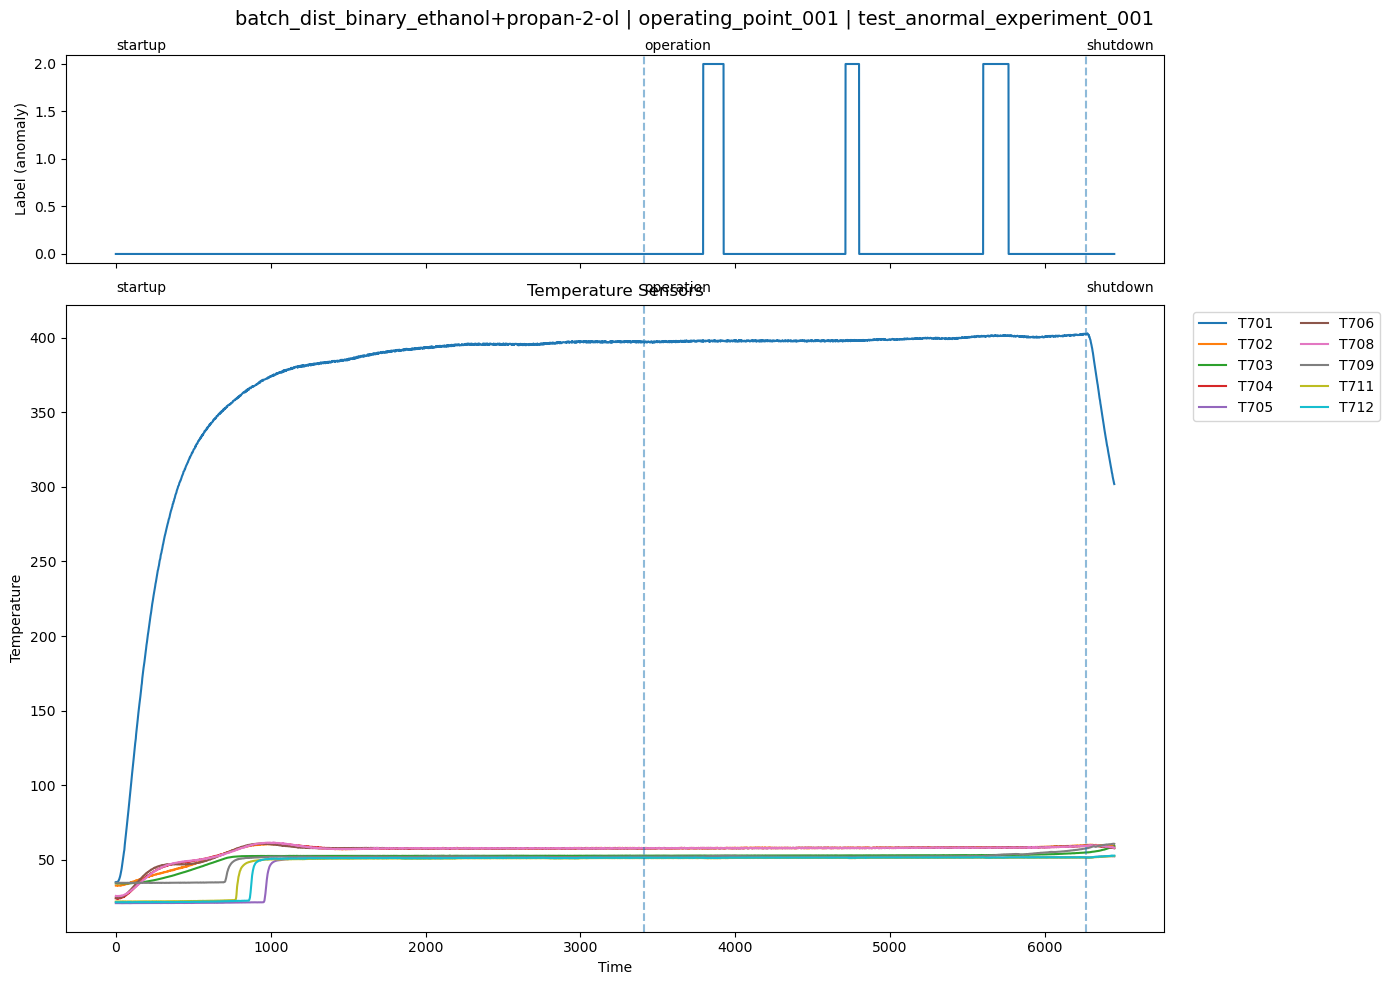

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# SETTINGS
# ============================================================

y = "Label (anomaly)"

temperatures = [
    'T701',
    'T702',
    'T703',
    'T704',
    'T705',
    'T706',
    'T708',
    'T709',
    'T711',
    'T712'
]

# ============================================================
# FIND PHASE BOUNDARIES
# ============================================================

phase_change = experiment["phase"].ne(experiment["phase"].shift())
phase_indices = experiment.index[phase_change]

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

ax_label = axes[0]
ax_temp = axes[1]

# ============================================================
# 1. ANOMALY LABEL
# ============================================================

sns.lineplot(
    data=experiment,
    x="elapsed_time",
    y=y,
    ax=ax_label
)

ax_label.set_ylabel(y)
ax_label.set_xlabel("")

# ============================================================
# 2. TEMPERATURES
# ============================================================

for feature in temperatures:

    sns.lineplot(
        data=experiment,
        x="elapsed_time",
        y=feature,
        ax=ax_temp,
        label=feature
    )

ax_temp.set_xlabel("Time")
ax_temp.set_ylabel("Temperature")
ax_temp.set_title("Temperature Sensors")

# ============================================================
# PHASE BOUNDARIES IN BOTH SUBPLOTS
# ============================================================

for start_idx in phase_indices:

    phase = experiment.loc[start_idx, "phase"]
    phase_time = experiment.loc[start_idx, "elapsed_time"]

    # Vertical boundary
    if start_idx != experiment.index[0]:

        for ax in axes:
            ax.axvline(
                phase_time,
                linestyle="--",
                alpha=0.5
            )

    # Phase label
    for ax in axes:

        ax.text(
            phase_time,
            1.02,
            phase,
            transform=ax.get_xaxis_transform(),
            ha="left"
        )

# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    f"{BATCH} | {OPERATING_POINT} | {TEST}",
    fontsize=14
)

# ============================================================
# LEGEND
# ============================================================

ax_temp.legend(
    ncol=2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    rf"{output_dir}/{BATCH}/{OPERATING_POINT}_{TEST}_anomaly_temp_ts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()